# Problem Statement
Insurance premiums are influenced by multiple factors that determine the cost covered by an insurance company.  
As a data analyst/scientist, you are given a set of historical data of an organization's customers with the Insurance charges levied. The dataset includes information such as age, sex, bmi, hospitalization history, annual income, etc.

Your task is to analyze the data, extract insights and build predictive models to estimate insurance charges for new customers.
The goal is to identify the model that best predicts insurance charges while understanding the key factors affecting the cost

### Dataset Explanation

| Feature                             | Description                                          |
| ----------------------------------- | ---------------------------------------------------- |
| **age**                             | Age of the individual                                |
| **sex**                             | Gender (male/female)                                 |
| **bmi**                             | Body Mass Index — a measure of body fat              |
| **children**                        | Number of dependents                                 |
| **smoker**                          | Whether the person is a smoker (yes/no)              |
| **Claim_Amount**                    | Previous insurance claim amount filed                |
| **past_consultations**              | Number of past medical consultations                 |
| **num_of_steps**                    | Average number of steps taken daily (activity level) |
| **Hospital_expenditure**            | Previous hospital spending                           |
| **Number_of_past_hospitalizations** | Count of past hospitalizations                       |
| **Annual_Salary**                   | Annual income of the individual                      |
| **region**                          | Residential region                                   |
| **charges** *(Target variable)*     | Total medical insurance charges                      |

### Importing Initial Python Packages

In [60]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore') 
import math

## Loading the dataset

In [61]:
insurance = pd.read_csv(r'D:\ds ai ml\DS@AI\00-portfolio-projects\01-Insurance Dataset- regression Analysis\insurance_data.csv')

In [62]:
insurance.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,Number_of_past_hospitalizations,Annual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [63]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   Number_of_past_hospitalizations  1336 non-null   float64
 10  Annual_Salary                    1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [64]:
insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'Number_of_past_hospitalizations', 'Annual_Salary', 'region',
       'charges'],
      dtype='object')

In [65]:
insurance.shape

(1338, 13)

## Exploratory Data Analysis (EDA)

In [66]:
insurance.describe().round().T   

,count,mean,std,min,25%,50%,75%,max
age,1329.0,39.0,14.0,18.0,27.0,39.0,51.0,6.400000e+01
bmi,1335.0,31.0,6.0,16.0,26.0,30.0,35.0,5.300000e+01
children,1333.0,1.0,1.0,0.0,0.0,1.0,2.0,5.000000e+00
Claim_Amount,1324.0,33361.0,15617.0,1920.0,20769.0,33700.0,45052.0,7.727800e+04
past_consultations,1332.0,15.0,7.0,1.0,9.0,15.0,20.0,4.000000e+01
num_of_steps,1335.0,910005.0,91886.0,695430.0,847200.0,914300.0,971684.0,1.107872e+06
Hospital_expenditure,1334.0,15841792.0,26693048.0,29453.0,4077633.0,7490337.0,10840822.0,2.616317e+08
Number_of_past_hospitalizations,1336.0,1.0,1.0,0.0,1.0,1.0,1.0,3.000000e+00
Annual_Salary,1332.0,369684860.0,566884292.0,2747072.0,77019323.0,141936093.0,324349867.0,4.117197e+09
charges,1338.0,13270.0,12110.0,1122.0,4740.0,9382.0,16640.0,6.377000e+04


In [67]:
insurance.describe(include='O')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


### Summary of categorical features

In [68]:
features = ['sex', 'smoker', 'region','children']
for col in features:
    print(f'\n{insurance[col].value_counts()}')


sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

children
0.0    574
1.0    321
2.0    240
3.0    156
4.0     25
5.0     17
Name: count, dtype: int64


### Categorial data visualization

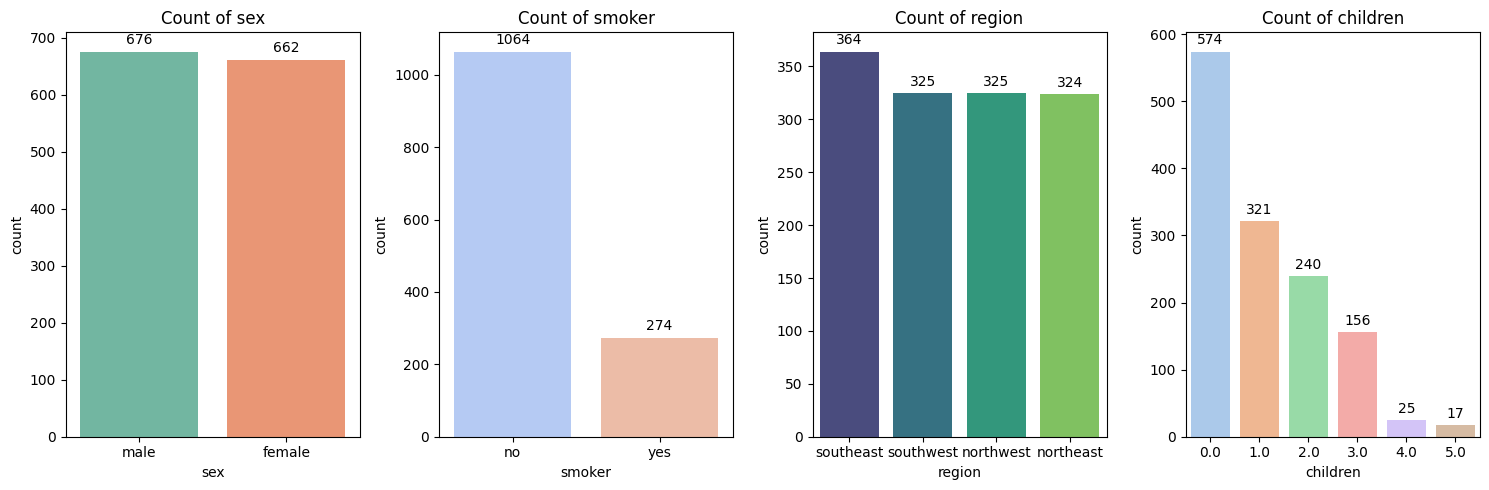

In [69]:
palettes = ['Set2', 'coolwarm', 'viridis', 'pastel']

fig, axes = plt.subplots(1, 4, figsize=(15,5))

for i, col in enumerate(features):
    ax = axes[i]
    
    sns.countplot(
        x=col,
        data=insurance,
        palette=palettes[i],
        ax=ax
    )
    
    ax.set_title(f'Count of {col}')
    
    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()


### Observations
The dataset is fairly balanced by gender, with slightly more males (676) than females (662). Most individuals are non-smokers (1,064), and the regions are evenly represented. The majority have no children or 1–2 children, while few have three or more, indicating mostly small families.

## Checking the distribution of each of the variables in the dataset  

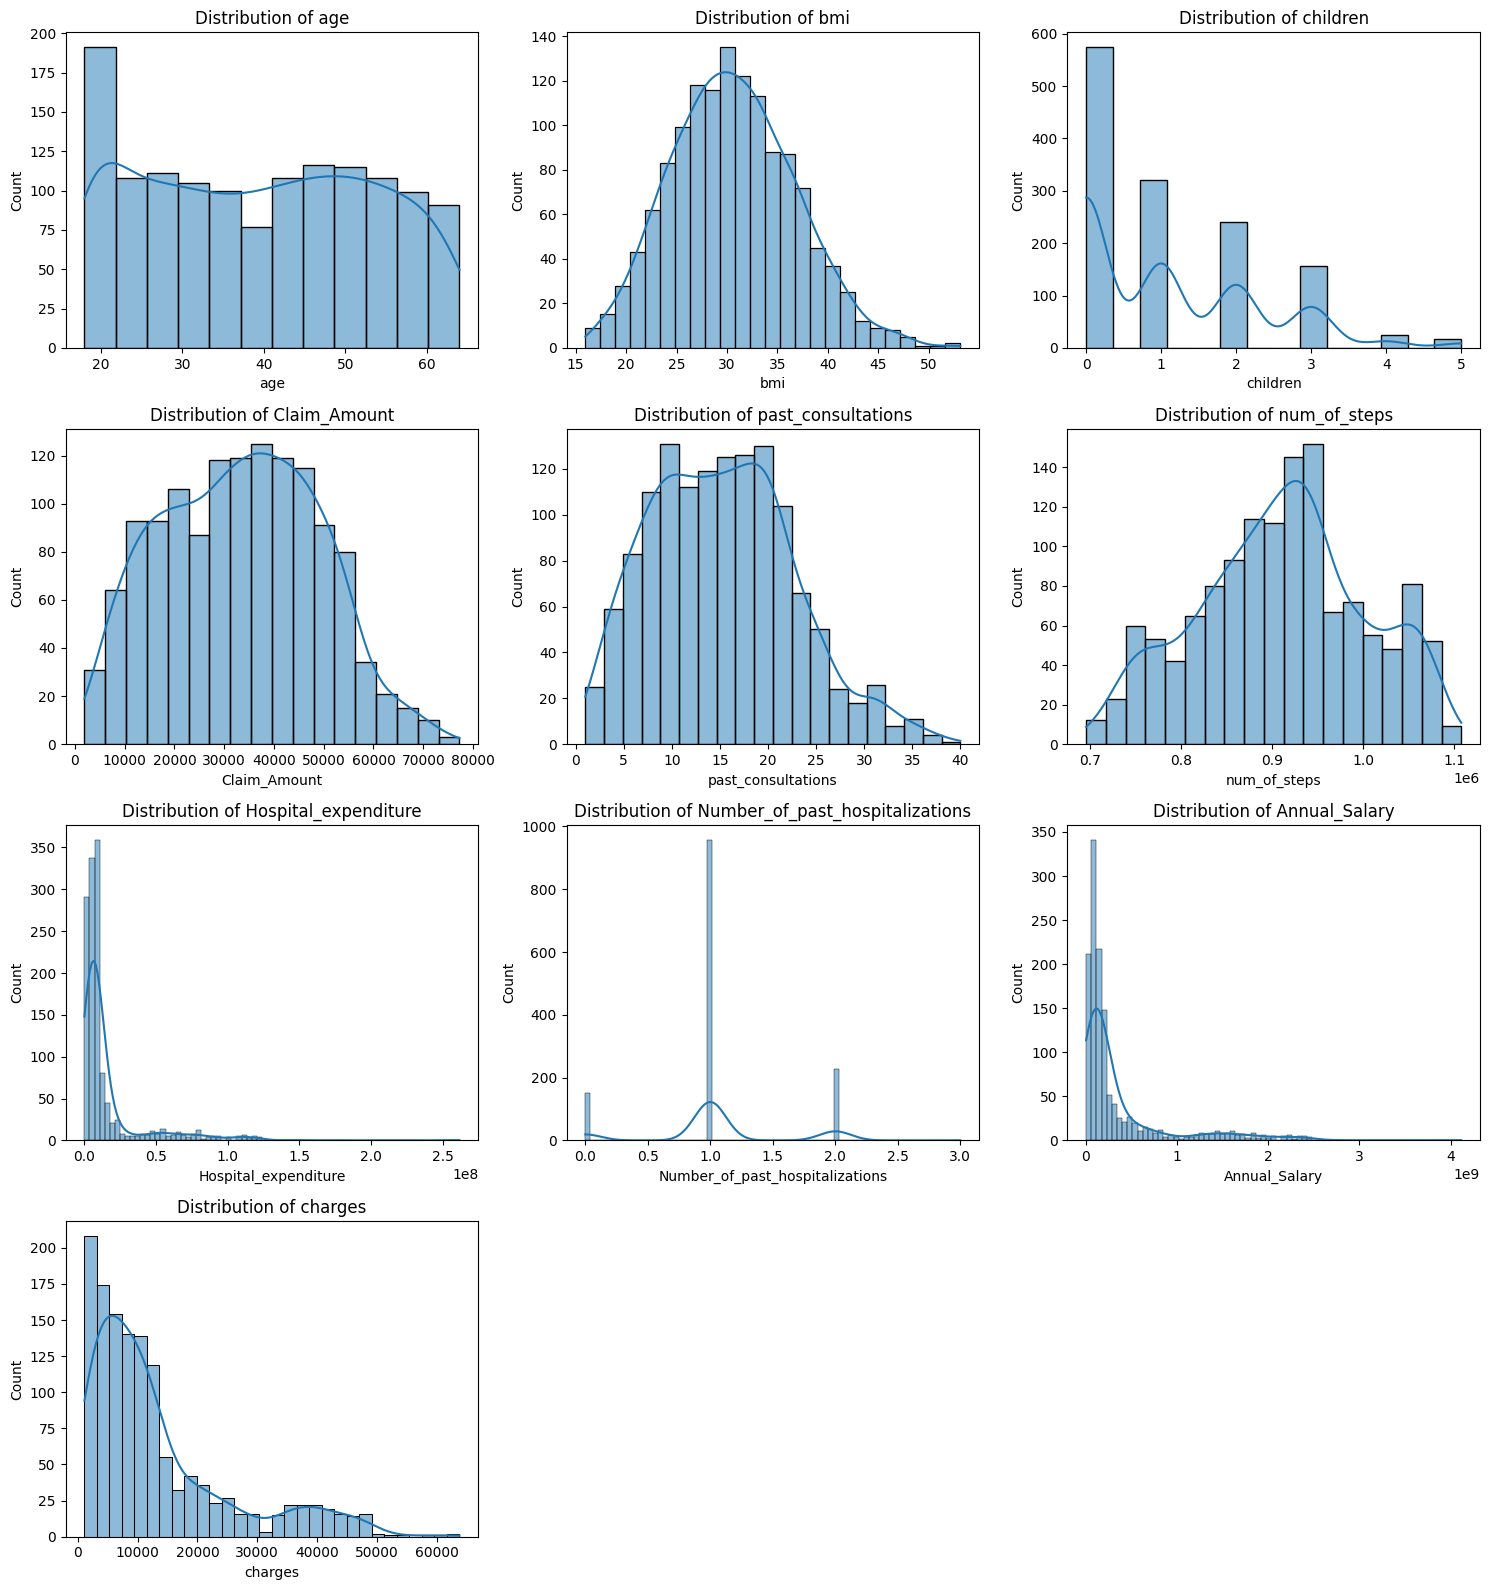

In [70]:
cols = insurance.select_dtypes(exclude='object').columns

n_plots = len(cols)
n_cols = 3                      # choose layout
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=insurance,
        x=col,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Only BMI column is normally distributed and other columns have skewded distribution    

## Outlier Analysis using Boxplots

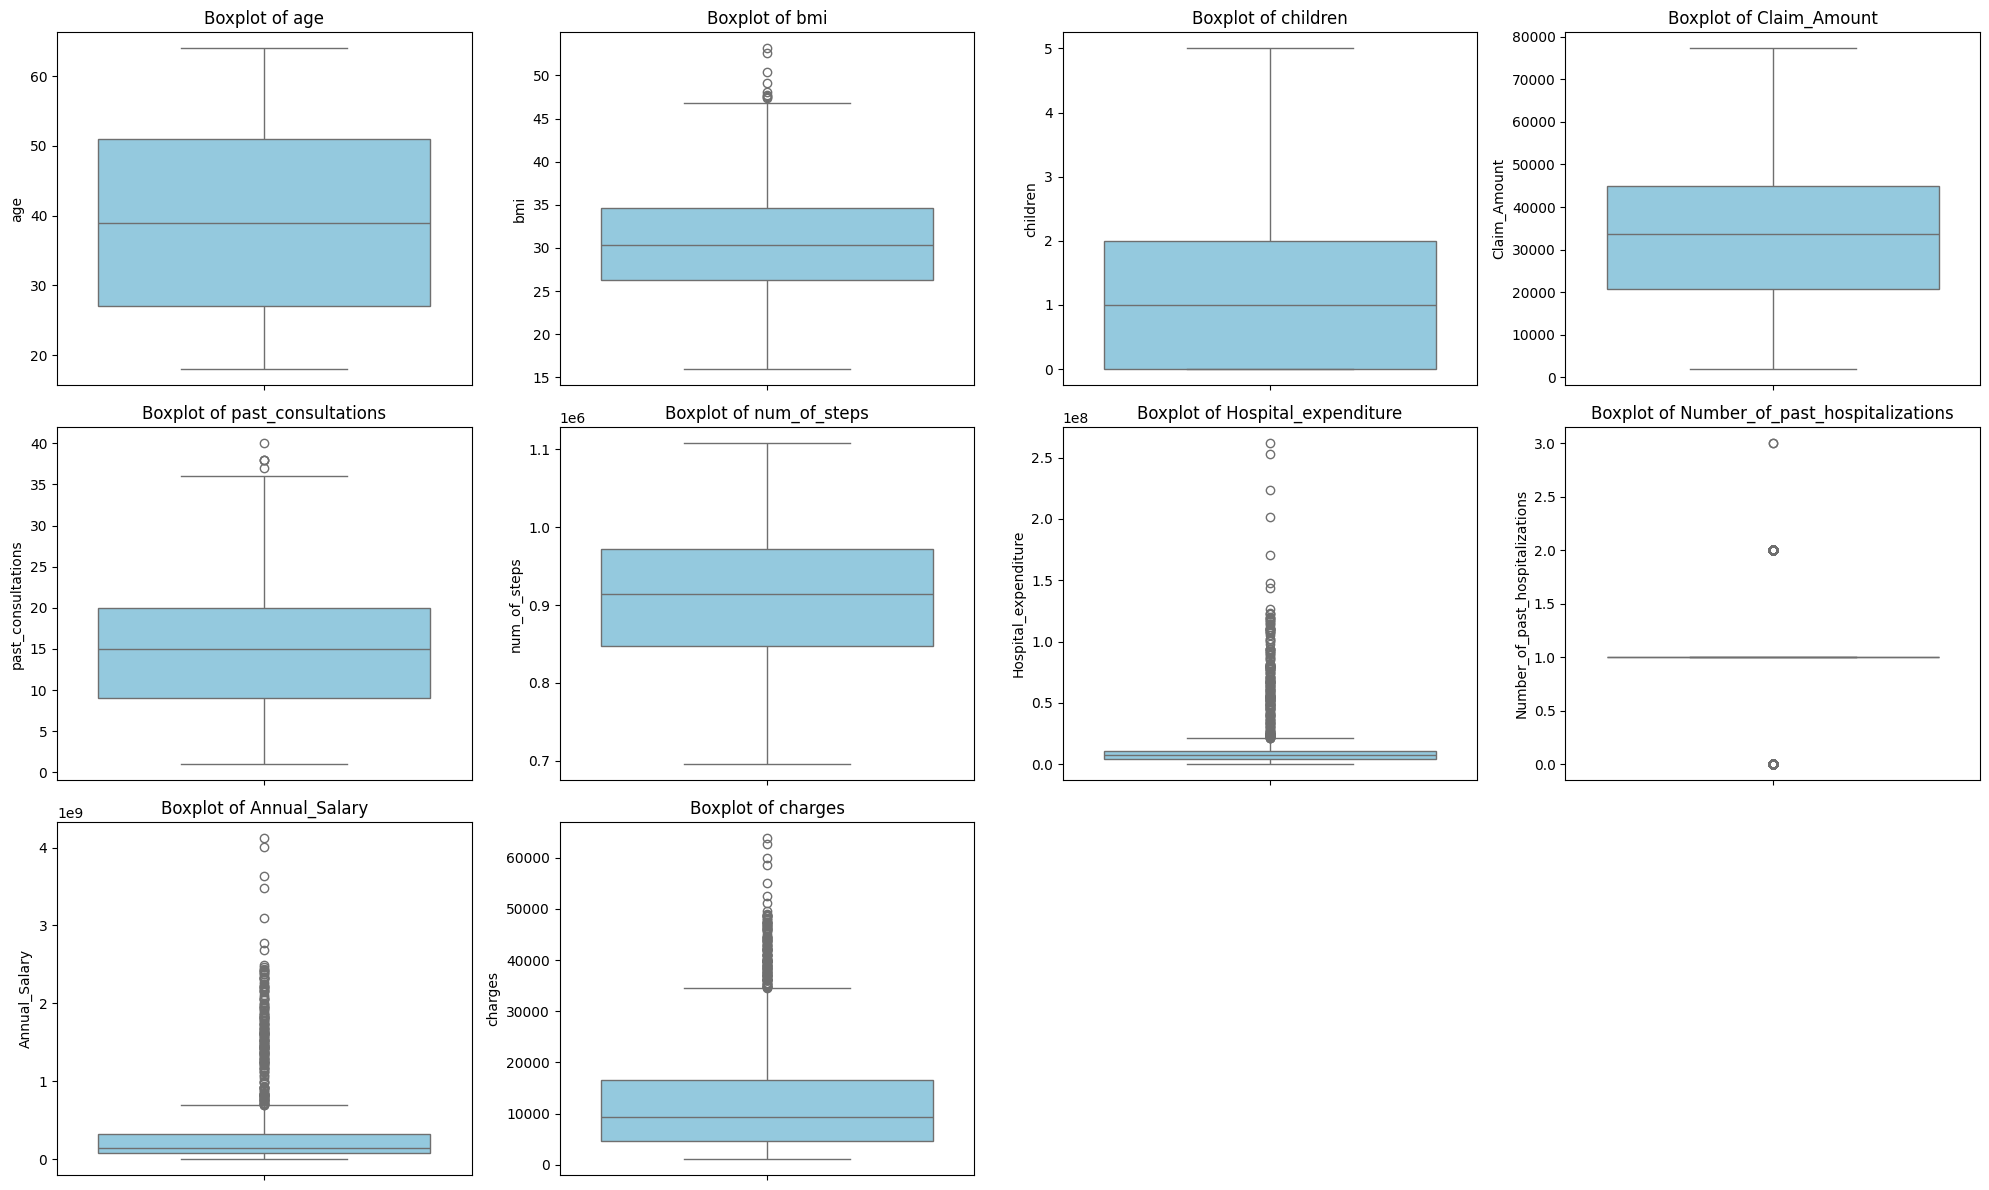

In [71]:
n_plots = len(cols)
n_cols = 4  # choose how many columns per row
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]    
    sns.boxplot(
        y=insurance[col],  # boxplot usually works with y
        ax=ax,
        color='skyblue')
    
    ax.set_title(f'Boxplot of {col}')
    ax.set_ylabel(col)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Interpretations from the plots
There is a presence of outliers in the columns 'charges', 'annual_salary', 'hospital_expenditure', 'past_consultations', 'bmi', etc. We will not treat the outliers, since the target variable also consists of outliers which is driven from the other independent variables.

## Understanding the relationship between the dependent and independent variables using a pairplot

<Figure size 1000x500 with 0 Axes>

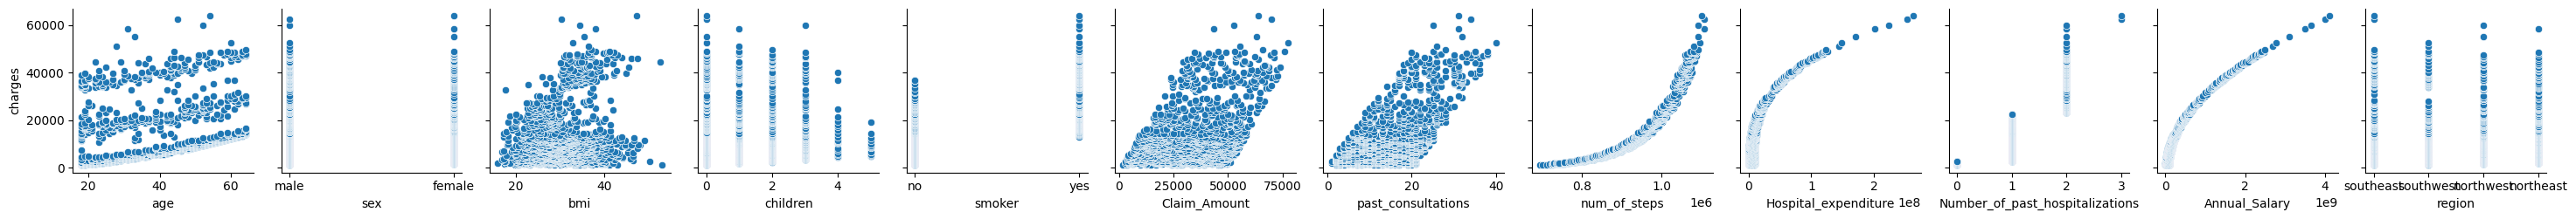

In [72]:
plt.figure(figsize=(10,5))
sns.pairplot(data=insurance, y_vars=['charges'], x_vars=['age',
                                                         'sex',
                                                         'bmi',
                                                         'children',
                                                         'smoker',
                                                         'Claim_Amount',
                                                         'past_consultations',
                                                         'num_of_steps',
                                                         'Hospital_expenditure',
                                                         'Number_of_past_hospitalizations',
                                                         'Annual_Salary',
                                                         'region'])

### Interpretations from the scatter plots
Several of the features shows a positive linear relationship with the target variable. These features will be further analyzed with respect to the correlation to reach a conclusion for their usability in the linear regression model.

## Missing Value Analysis

In [73]:
insurance.isna().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
Number_of_past_hospitalizations     2
Annual_Salary                       6
region                              0
charges                             0
dtype: int64

In [74]:
insurance['bmi'] = insurance['bmi'].fillna(insurance['bmi'].mean())

In [75]:
insurance.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'Number_of_past_hospitalizations', 'Annual_Salary', 'region',
       'charges'],
      dtype='object')

In [76]:
cols = ['age','children','Claim_Amount','past_consultations','num_of_steps','Hospital_expenditure','Number_of_past_hospitalizations', 'Annual_Salary']

In [77]:
for col in cols:
    insurance[col]=insurance[col].fillna(insurance[col].median())

In [78]:
insurance.isna().sum()

age                                0
sex                                0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
Number_of_past_hospitalizations    0
Annual_Salary                      0
region                             0
charges                            0
dtype: int64

### Approach for data imputation in the insurance data.
1. Null values are replaced with the mean in columns where it showed normal distribution i.e  bmi
2. For the distributions that showed a skewed distribution, we have replaced the null values with the median of the column.

## Duplicates

In [79]:
insurance.duplicated().sum()

np.int64(0)

## Encoding

In [80]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols = insurance.select_dtypes(include = 'object').columns

encoders = {}
for col in cols:
    le = LabelEncoder()
    insurance[col] = le.fit_transform(insurance[col])
    encoders[col] = le
insurance.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,Number_of_past_hospitalizations,Annual_Salary,region,charges
0,18.0,1,23.21,0.0,0,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,2,1121.8739
1,18.0,1,30.14,0.0,0,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,2,1131.5066
2,18.0,1,33.33,0.0,0,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,2,1135.9407
3,18.0,1,33.66,0.0,0,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,2,1136.3994
4,18.0,1,34.10,0.0,0,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,2,1137.0110


## Feature Selection for Data Modeling

In [81]:
correlation = insurance.corr()
correlation

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,Number_of_past_hospitalizations,Annual_Salary,region,charges
age,1.000000,-0.019154,0.112165,0.041710,-0.028792,0.122873,0.168479,0.513066,0.137208,0.359637,0.163478,0.004623,0.293735
sex,-0.019154,1.000000,0.045170,0.018533,0.076185,-0.003821,0.050274,0.010445,0.069940,0.000214,0.072702,0.004588,0.057292
bmi,0.112165,0.045170,1.000000,0.007755,0.003610,0.093364,0.130720,0.135930,0.256892,0.137043,0.241505,0.158261,0.198691
children,0.041710,0.018533,0.007755,1.000000,0.009608,0.041607,0.054806,0.163478,0.025315,0.185546,0.041260,0.015011,0.070877
smoker,-0.028792,0.076185,0.003610,0.009608,1.000000,0.334410,0.502794,0.665656,0.662698,0.588682,0.739676,-0.002181,0.787251
Claim_Amount,0.122873,-0.003821,0.093364,0.041607,0.334410,1.000000,0.271526,0.398285,0.369988,0.379923,0.404026,0.009098,0.435671
past_consultations,0.168479,0.050274,0.130720,0.054806,0.502794,0.271526,1.000000,0.559692,0.542150,0.500145,0.589292,-0.001864,0.627598
num_of_steps,0.513066,0.010445,0.135930,0.163478,0.665656,0.398285,0.559692,1.000000,0.624790,0.844983,0.733622,-0.041938,0.889753
Hospital_expenditure,0.137208,0.069940,0.256892,0.025315,0.662698,0.369988,0.542150,0.624790,1.000000,0.651827,0.957189,0.029446,0.871796
Number_of_past_hospitalizations,0.359637,0.000214,0.137043,0.185546,0.588682,0.379923,0.500145,0.844983,0.651827,1.000000,0.735802,-0.031450,0.820682


### Inferences
There is a strong to moderate correlation with the charges column with the following columns:
1. smoker
2. Claim_Amount
3. past_consultations
4. num_of_steps
5. Hospital_expenditure
6. Number_of_past_hospitalizations
7. Annual_Salary

The column 'age', 'sex', 'region', 'children', 'bmi' shows no considerable correlation with the charges column, so we will not be considering these features for the initial model.


<Axes: >

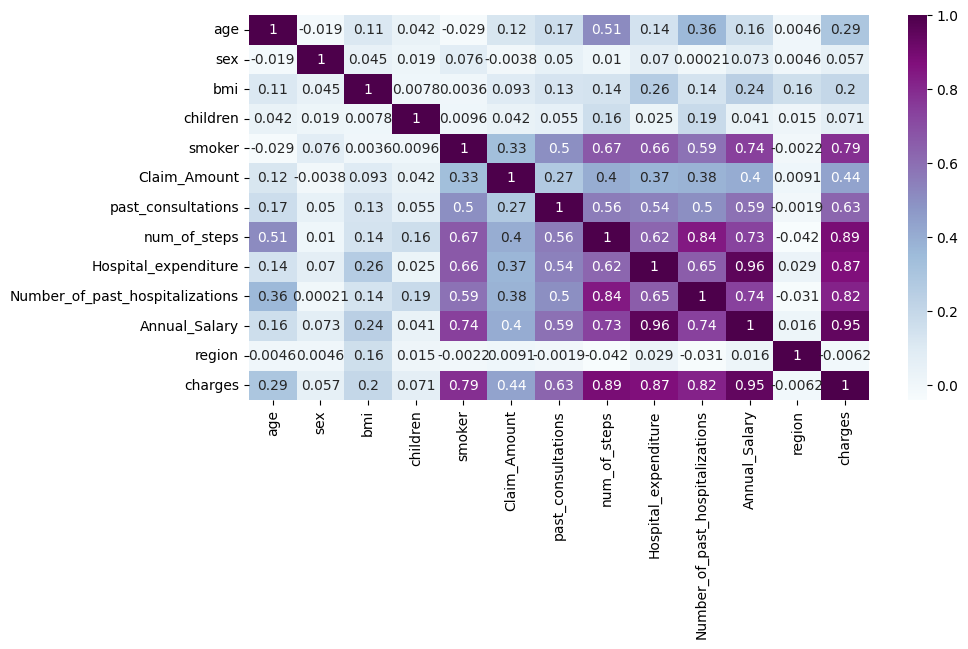

In [82]:
plt.figure(figsize=(10,5))
sns.heatmap(correlation, annot = True, cmap = 'BuPu')

The correlation heatmap shows the columns that will be most useful for the modeling. The sex, children, bmi, age and region column shows no considerable correlation.

## Data Preprocessing Before Model Training

In [83]:
from sklearn.model_selection import train_test_split

X = insurance.drop(['charges', 'age', 'sex', 'bmi', 'children', 'region'], axis=1)
y = insurance['charges']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=1)


In [84]:
y_train

216      3309.79260
731     10355.64100
866     12333.82800
202      3176.28770
820     11674.13000
           ...     
715     10085.84600
905     13041.92100
1096    21880.82000
235      3558.62025
1061    19749.38338
Name: charges, Length: 1070, dtype: float64

In [85]:
X_train

,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,Number_of_past_hospitalizations,Annual_Salary
216,0,13041.90483,4.0,815477.0,1.273883e+06,1.0,3.933610e+07
731,0,15301.88507,17.0,916445.0,3.355828e+06,1.0,1.250280e+08
866,0,22670.05311,20.0,947996.0,6.133821e+06,1.0,1.670188e+08
202,0,22630.60525,9.0,820196.0,5.490229e+06,1.0,1.642620e+07
820,0,38655.63504,19.0,928213.0,4.734405e+06,1.0,2.259281e+08
...,...,...,...,...,...,...,...
715,0,27731.37254,8.0,920050.0,2.785092e+06,1.0,1.312519e+08
905,0,33885.79768,21.0,945757.0,7.966184e+06,1.0,2.516949e+08
1096,1,35000.50338,15.0,1005596.0,1.899002e+07,1.0,4.946560e+08
235,0,18767.94647,15.0,815981.0,2.247799e+06,1.0,2.946028e+07


In [86]:
X_test

,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,Number_of_past_hospitalizations,Annual_Salary
559,0,33330.50185,21.0,885629.0,6.868865e+06,1.0,7.559974e+07
1087,0,51309.90642,28.0,999088.0,1.394561e+07,1.0,5.047760e+08
1020,1,38360.96691,16.0,973272.0,1.301319e+07,1.0,3.930467e+08
460,0,51373.64190,12.0,863605.0,1.000634e+07,1.0,5.488337e+07
802,0,12992.13995,24.0,933863.0,4.075903e+06,1.0,2.061268e+08
...,...,...,...,...,...,...,...
682,0,27425.19835,5.0,908350.0,1.870300e+06,1.0,1.058095e+08
629,0,20322.78532,14.0,899405.0,8.414212e+05,1.0,1.451129e+08
893,0,56840.23864,24.0,943649.0,8.228465e+06,1.0,1.749679e+08
807,0,38473.01782,21.0,919690.0,2.087158e+06,1.0,1.449292e+08


### Standardizing the features

In [87]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [88]:
y_train = y_train.values.reshape((-1,1)) 
y_test = y_test.values.reshape((-1,1)) 

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.transform(y_test)


## Function to calculate evaluation metrics

In [89]:
from sklearn.metrics import r2_score, mean_squared_error
def get_model_metrics(model, X_train, X_test,y_train,y_test, flag = True):

     # defining an empty list to store train and test results
    score_list=[]

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_r2=r2_score(y_train,pred_train)
    test_r2=r2_score(y_test,pred_test)
    train_rmse=np.sqrt(mean_squared_error(y_train,pred_train))
    test_rmse=np.sqrt(mean_squared_error(y_test,pred_test))

    #Adding all scores in the list
    score_list.extend((train_r2,test_r2,train_rmse,test_rmse))  


    # If the flag is set to True then only the following print statements will be dispayed, the default value is True
    if flag==True:
        print("R-sqaure on training set : ", train_r2)
        print("R-square on test set : ",     test_r2)
        print("RMSE on training set : ",     train_rmse)
        print("RMSE on test set : ",         test_rmse)

    # returning the list with train and test scores
    return score_list
       
    

## Model Building

### Linear Regression

In [90]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()

linear_regression.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [91]:
results_LR = get_model_metrics(linear_regression, X_train, X_test,y_train,y_test, flag = True)

R-sqaure on training set :  0.9808291792929364
R-square on test set :  0.9852682818612359
RMSE on training set :  0.13845873286674112
RMSE on test set :  0.11010132881323902


#### observations
The Linear Regression model performed very well, achieving R² of 0.981 (training) and 0.985 (test), indicating it explains over 98% of the variance in charges. The RMSE values of 0.138 (training) and 0.110 (test) show that predictions are highly accurate with low error, and the model generalizes well.

## Decision Tree Regressor

In [92]:
from sklearn.tree import DecisionTreeRegressor
decision_tree = DecisionTreeRegressor()
decision_tree.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [93]:
results_DT = get_model_metrics(decision_tree, X_train, X_test,y_train,y_test, flag = True)

R-sqaure on training set :  1.0
R-square on test set :  0.9946037288728845
RMSE on training set :  0.0
RMSE on test set :  0.06663658635692588


#### Observation
The Decision Tree Regressor achieved R² of 1.0 (training) and 0.995 (test) with RMSE 0.0 (training) and 0.065 (test), showing excellent predictions, though the perfect training fit indicates potential overfitting.

#### Hyperparameter tuning

In [94]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
dtree_tuned = DecisionTreeRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {'max_depth': list(np.arange(2,20)) + [None],
              'min_samples_leaf': [1, 3, 5, 7, 10],
              'max_leaf_nodes' : [2, 3, 5, 10, 15] + [None], 
              'min_impurity_decrease': [0.001, 0.01, 0.1, 0.0]
             }

scorer = make_scorer(r2_score)
   
# Run the grid search
grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=scorer,cv=5, n_jobs = -1)

grid_obj = grid_obj.fit(X_train, y_train)

dtree_tuned = grid_obj.best_estimator_
print("Best parameters:", grid_obj.best_params_)
print("Best R² score:", grid_obj.best_score_)


# Fit the best algorithm to the data.
dtree_tuned.fit(X_train, y_train)

Best parameters: {'max_depth': np.int64(7), 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3}
Best R² score: 0.9903771358579292


,criterion,'squared_error'
,splitter,'best'
,max_depth,np.int64(7)
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [95]:
results_DTune = get_model_metrics(dtree_tuned, X_train, X_test,y_train,y_test, flag = True)

R-sqaure on training set :  0.9979726076433717
R-square on test set :  0.9960266791121553
RMSE on training set :  0.045026573893961135
RMSE on test set :  0.0571798063521159


#### Observation
After hyperparameter tuning, the Decision Tree Regressor achieved R² of 0.998 (training) and 0.996 (test) with RMSE of 0.045 (training) and 0.057 (test). Limiting the tree depth and minimum samples per leaf reduced overfitting while maintaining excellent predictive performance, ensuring the model is robust and generalizes well to new data.

## Random Forest Model

In [96]:
from sklearn.ensemble import RandomForestRegressor
random_forest = RandomForestRegressor()
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
rf_results = get_model_metrics(random_forest, X_train, X_test,y_train,y_test, flag = True)

R-sqaure on training set :  0.998905919229689
R-square on test set :  0.997446731684953
RMSE on training set :  0.03307689178733422
RMSE on test set :  0.045836778607714554


#### Hyperparameter tuning

In [98]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
random_forest_tuned = RandomForestRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {  'max_depth':[4, 6, 8, 10, None],
                'max_features': ['sqrt','log2',None],
                'n_estimators': [80, 90, 100, 110, 120]  # number of decision tree
}

scorer = make_scorer(r2_score)
   
# Run the grid search
grid_obj = GridSearchCV(random_forest_tuned, parameters, scoring=scorer,cv=5, n_jobs = -1)

grid_obj = grid_obj.fit(X_train, y_train)

random_forest_tuned = grid_obj.best_estimator_
print("Best parameters:", grid_obj.best_params_)
print("Best R² score:", grid_obj.best_score_)


# Fit the best algorithm to the data.
random_forest_tuned.fit(X_train, y_train)

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 90}
Best R² score: 0.9952977684249851


,n_estimators,90
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
rf_tune_results = get_model_metrics(random_forest_tuned, X_train, X_test,y_train,y_test, flag = True)

R-sqaure on training set :  0.9993046632429375
R-square on test set :  0.9965062253430452
RMSE on training set :  0.0263692388411666
RMSE on test set :  0.05361833269917357


#### Observation
The tuned Random Forest achieved R² of 0.999 (training) and 0.997 (test) with RMSE of 0.026 (training) and 0.054 (test), showing highly accurate predictions and strong generalization. Hyperparameter tuning improved robustness while maintaining excellent performance, making it the most reliable model for predicting insurance charges.

### Visualization of evaluation metrics

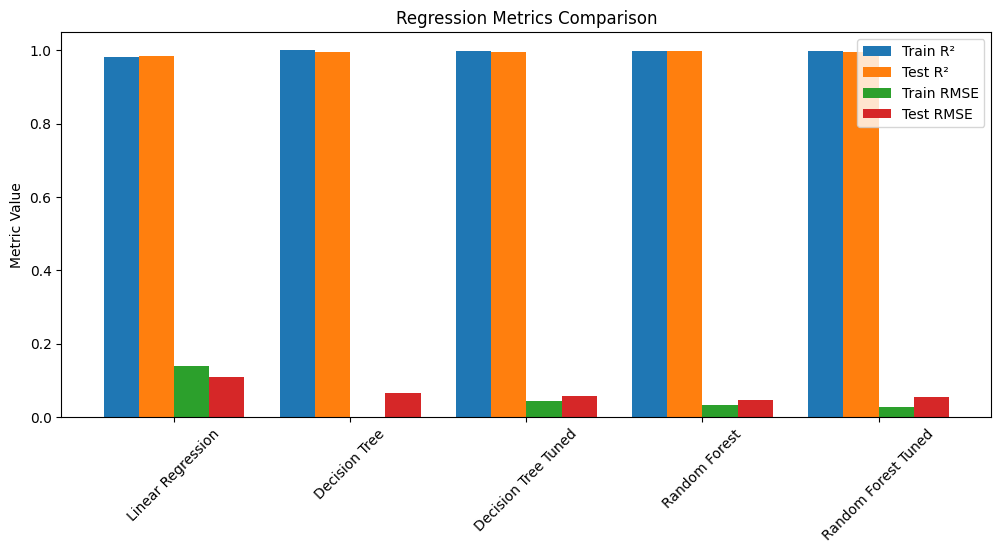

In [100]:
# Metrics stored as lists: [train_r2, test_r2, train_rmse, test_rmse]
models_metrics = {
    'Linear Regression': results_LR,
    'Decision Tree': results_DT,
    'Decision Tree Tuned': results_DTune,
    'Random Forest': rf_results,
    'Random Forest Tuned': rf_tune_results
}

models = list(models_metrics.keys())
train_r2 = [m[0] for m in models_metrics.values()]
test_r2 = [m[1] for m in models_metrics.values()]
train_rmse = [m[2] for m in models_metrics.values()]
test_rmse = [m[3] for m in models_metrics.values()]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,5))

plt.bar(x - 1.5*width, train_r2, width, label='Train R²')
plt.bar(x - 0.5*width, test_r2, width, label='Test R²')
plt.bar(x + 0.5*width, train_rmse, width, label='Train RMSE')
plt.bar(x + 1.5*width, test_rmse, width, label='Test RMSE')

plt.xticks(x, models, rotation=45)
plt.ylabel('Metric Value')
plt.title('Regression Metrics Comparison')
plt.legend()
plt.show()


## Best Model selection
The comparison shows that all models perform well, with tree-based models generally outperforming Linear Regression. Single Decision Trees fit the training data perfectly but risk overfitting, while hyperparameter tuning reduces this and improves robustness. 

**Random Forests**, especially the tuned version, achieve the highest accuracy and lowest errors, making them the most reliable models for predicting insurance charges.

## Model deployment

In [101]:
import joblib
joblib.dump(random_forest_tuned,"rf_tuned_model.pkl")  # Save the model
joblib.dump(sc_X, "sc_X.pkl")
joblib.dump(sc_y, "sc_y.pkl")


['sc_y.pkl']

In [ ]:
import gradio as gr
import pandas as pd
import joblib


model = joblib.load("rf_tuned_model.pkl")

sc_X = joblib.load("sc_X.pkl")
sc_y = joblib.load("sc_y.pkl")

# Map categorical to numbers
smoker_map = {'no': 0, 'yes': 1}

# Prediction function
def predict(smoker, Claim_Amount,
            past_consultations, num_of_steps, Hospital_expenditure,
            Number_of_past_hospitalizations, Annual_Salary):
       
    # Convert smoker to numeric
    smoker_num = smoker_map[smoker]
    X = [[
        smoker_num,
        Claim_Amount,
        past_consultations,
        num_of_steps,
        Hospital_expenditure,
        Number_of_past_hospitalizations,
        Annual_Salary
    ]]
    X_scaled = sc_X.transform(X)
    y_scaled_pred = model.predict(X_scaled).reshape(-1, 1)
    y_pred = sc_y.inverse_transform(y_scaled_pred)

    return round(float(y_pred[0][0]), 2)

    
# Define Gradio inputs
inputs = [
    gr.Dropdown(choices=['yes', 'no'], label='Smoker'),
    gr.Number(label='Claim Amount'),
    gr.Number(label='Past Consultations'),
    gr.Number(label='Num of Steps'),
    gr.Number(label='Hospital Expenditure'),
    gr.Number(label='Number of Past Hospitalizations'),
    gr.Number(label='Annual Salary')
 ]

# Add examples 
examples = [
    ['no', 29087.54313, 17.0, 715428.0, 4720920.992, 0.0, 55784970.05,],
    ['no', 39053.67437, 7.0, 699157.0, 4329831.676, 0.0, 13700885.19,]
]

# Create Gradio interface
interface = gr.Interface(
    fn=predict,
    inputs=inputs,
    outputs=gr.Number(label="Predicted Charges"),
    examples=examples,
    cache_examples=False,
    title="Insurance Charges Predictor",
    description="Predict insurance charges based on patient and hospital data"
)

# Launch app
if __name__ == "__main__":
    interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7873
